In [33]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
pyngrok
plotly
requests
langchain

Writing requirements.txt


In [34]:
import warnings
warnings.filterwarnings('ignore')

# Install all necessary packages from requirements.txt
!pip install -q -r requirements.txt

In [2]:
# The following lines are commented out due to persistent dependency conflicts with langchain and pydantic.
# If AI guidance features are desired, consider using a separate environment or a different approach for dependency management.
# !pip install langchain-core==0.1.37 langchain-openai pydantic==1.10.13 -q

import sqlite3
import random
# from langchain_core.prompts import PromptTemplate
# from langchain_core.output_parsers import StrOutputParser
# from langchain_openai import ChatOpenAI
import os

In [35]:
import sqlite3

conn = sqlite3.connect("health.db")
cur = conn.cursor()

# Enable foreign key support
cur.execute("PRAGMA foreign_keys = ON;")

# 1. Create patients table
cur.execute("""
CREATE TABLE IF NOT EXISTS patients (
    patient_name TEXT PRIMARY KEY
)
""")

# 2. Create medications table (updated with FOREIGN KEY)
cur.execute("""
CREATE TABLE IF NOT EXISTS medications (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_name TEXT,
    medicine_name TEXT,
    dosage TEXT,
    time_str TEXT,
    FOREIGN KEY (patient_name) REFERENCES patients (patient_name) ON DELETE CASCADE
)
""")

# 3. Create health_metrics table (as requested by user)
cur.execute("""
CREATE TABLE IF NOT EXISTS health_metrics (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_name TEXT,
    log_date TEXT,
    steps INTEGER,
    calories INTEGER,
    sleep REAL,
    systolic INTEGER,
    diastolic INTEGER,
    heart_rate INTEGER,
    FOREIGN KEY (patient_name) REFERENCES patients (patient_name) ON DELETE CASCADE
)
""")

# Clear existing data for a clean run if tables are being re-created
cur.execute("DELETE FROM medications")
cur.execute("DELETE FROM patients") # Clear patients too if re-running setup
cur.execute("DELETE FROM health_metrics") # Clear health_metrics

sample_medication_data = [
    ("sanju", "Paracetamol", "500mg", "08:00"),
    ("sneha", "Vitamin D", "1 tablet", "20:00"),
    ("Anita", "Metformin", "500mg", "09:00")
]

# Insert distinct patient names into the patients table first
distinct_patients = list(set([d[0] for d in sample_medication_data]))
for patient in distinct_patients:
    cur.execute("INSERT OR IGNORE INTO patients (patient_name) VALUES (?)", (patient,))

# Insert medication data
cur.executemany(
    "INSERT INTO medications (patient_name, medicine_name, dosage, time_str) VALUES (?,?,?,?)",
    sample_medication_data
)

# Add some sample health_metrics data
sample_health_metrics_data = [
    ("sanju", "2024-01-01", 7500, 2200, 7.0, 120, 80, 70),
    ("sneha", "2024-01-01", 6000, 1800, 6.5, 115, 75, 65),
    ("Anita", "2024-01-01", 8000, 2500, 7.2, 125, 82, 72)
]
cur.executemany(
    "INSERT INTO health_metrics (patient_name, log_date, steps, calories, sleep, systolic, diastolic, heart_rate) VALUES (?,?,?,?,?,?,?,?)",
    sample_health_metrics_data
)

conn.commit()
conn.close()
print("Database ready.")

Database ready.


In [4]:
# Original langchain related code has been removed due to dependency conflicts.

def fake_health_metrics():
    import random
    steps = random.randint(2000, 9000)
    calories = random.randint(1500, 2600)
    sleep_hours = round(random.uniform(4.0, 8.0), 1)
    return steps, calories, sleep_hours

In [5]:
# 1) simulate health metrics
steps, calories, sleep_hours = fake_health_metrics()
print("=== Health Metrics ===")
print("Steps:", steps)
print("Calories:", calories)
print("Sleep hours:", sleep_hours)

# The AI Health Guidance (LangChain) part has been removed due to dependency conflicts.
# print("\n=== AI Health Guidance (LangChain) ===")
# try:
#     advice = health_chain.invoke({
#         "steps": str(steps),
#         "calories": str(calories),
#         "sleep_hours": str(sleep_hours)
#     })
#     print(advice)
# except Exception as e:
#     print(f"AI call failed: {e}")

# 3) show medication schedule from SQLite (health.db)
import sqlite3
conn = sqlite3.connect("health.db")
cur = conn.cursor()
cur.execute("SELECT patient_name, medicine_name, dosage, time_str FROM medications")
rows = cur.fetchall()
conn.close()

print("\n=== Medication Schedule (from health.db) ===")
for p, med, dose, t in rows:
    print(f"{p}: {med} ({dose}) at {t}")

=== Health Metrics ===
Steps: 8861
Calories: 1987
Sleep hours: 6.5

=== Medication Schedule (from health.db) ===
sanju: Paracetamol (500mg) at 08:00
sneha: Vitamin D (1 tablet) at 20:00
Anita: Metformin (500mg) at 09:00


=== Weekly Fitness Data ===
   Day  Steps  Calories  SleepHours
0    1   8569      2027         6.1
1    2   7722      1791         6.5
2    3   8561      2095         7.9
3    4   3692      2179         4.3
4    5   3312      1824         4.5
5    6   6427      2250         6.7
6    7   7864      2350         5.8


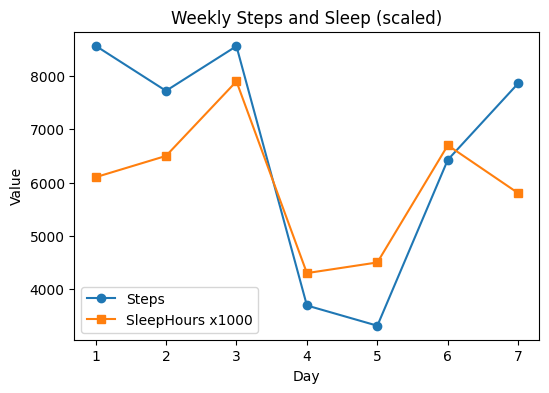

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# collect fake fitness data for 7 days using your existing fake_health_metrics()
days = list(range(1, 8))
steps_list = []
calories_list = []
sleep_list = []

for d in days:
    s, c, sl = fake_health_metrics()
    steps_list.append(s)
    calories_list.append(c)
    sleep_list.append(sl)

fitness_df = pd.DataFrame({
    "Day": days,
    "Steps": steps_list,
    "Calories": calories_list,
    "SleepHours": sleep_list
})

print("=== Weekly Fitness Data ===")
print(fitness_df)

plt.figure(figsize=(6,4))
plt.plot(fitness_df["Day"], fitness_df["Steps"], marker="o", label="Steps")
plt.plot(fitness_df["Day"], fitness_df["SleepHours"] * 1000, marker="s", label="SleepHours x1000")
plt.xlabel("Day")
plt.ylabel("Value")
plt.title("Weekly Steps and Sleep (scaled)")
plt.legend()
plt.show()


In [7]:
def generate_health_report(patient_name):
    # use existing fake_health_metrics()
    steps, calories, sleep_hours = fake_health_metrics()

    conn = sqlite3.connect("health.db")
    cur = conn.cursor()
    cur.execute("SELECT medicine_name, dosage, time_str FROM medications WHERE patient_name = ?", (patient_name,))
    meds = cur.fetchall()
    conn.close()

    activity_level = "low" if steps < 5000 else "good"
    sleep_comment = "could improve" if sleep_hours < 6 else "okay"

    report_lines = []
    report_lines.append(f"Health Report for {patient_name}")
    report_lines.append("-" * 30)
    report_lines.append(f"Daily steps: {steps} ({activity_level} activity)")
    report_lines.append(f"Calories: {calories}")
    report_lines.append(f"Sleep hours: {sleep_hours} ({sleep_comment})")
    report_lines.append("")
    report_lines.append("Medications:")
    if meds:
        for med, dose, t in meds:
            report_lines.append(f"- {med} ({dose}) at {t}")
    else:
        report_lines.append("No medications found in record.")

    return "\n".join(report_lines)

print("\n=== Sample Health Report ===")
print(generate_health_report("sneha"))



=== Sample Health Report ===
Health Report for sneha
------------------------------
Daily steps: 7003 (good activity)
Calories: 2140
Sleep hours: 6.1 (okay)

Medications:
- Vitamin D (1 tablet) at 20:00


In [8]:
import json
import xml.etree.ElementTree as ET

data = [
    {"day": 1, "steps": 4500, "calories": 1900},
    {"day": 2, "steps": 6200, "calories": 2100},
    {"day": 3, "steps": 3000, "calories": 1800}
]

# save CSV
csv_df = pd.DataFrame(data)
csv_df.to_csv("health_data.csv", index=False)

# save JSON
with open("health_data.json", "w") as f:
    json.dump(data, f)

# save XML
root = ET.Element("healthdata")
for row in data:
    rec = ET.SubElement(root, "record")
    for k, v in row.items():
        child = ET.SubElement(rec, k)
        child.text = str(v)
tree = ET.ElementTree(root)
tree.write("health_data.xml")

print("Saved health_data.csv, health_data.json, health_data.xml")

# read CSV
df_csv = pd.read_csv("health_data.csv")
print("\n=== CSV Data ===")
print(df_csv)

# read JSON
with open("health_data.json") as f:
    json_data = json.load(f)
df_json = pd.DataFrame(json_data)
print("\n=== JSON Data ===")
print(df_json)

# read XML
tree = ET.parse("health_data.xml")
root = tree.getroot()
xml_rows = []
for rec in root.findall("record"):
    day = int(rec.find("day").text)
    steps = int(rec.find("steps").text)
    calories = int(rec.find("calories").text)
    xml_rows.append({"day": day, "steps": steps, "calories": calories})
df_xml = pd.DataFrame(xml_rows)
print("\n=== XML Data ===")
print(df_xml)


Saved health_data.csv, health_data.json, health_data.xml

=== CSV Data ===
   day  steps  calories
0    1   4500      1900
1    2   6200      2100
2    3   3000      1800

=== JSON Data ===
   day  steps  calories
0    1   4500      1900
1    2   6200      2100
2    3   3000      1800

=== XML Data ===
   day  steps  calories
0    1   4500      1900
1    2   6200      2100
2    3   3000      1800


In [9]:
health_goals = {
    "steps_per_day": 6000,
    "sleep_hours": 7
}

def check_goals():
    steps, calories, sleep_hours = fake_health_metrics()
    print("\n=== Goal Progress Check ===")
    print("Today steps:", steps, "| Goal:", health_goals["steps_per_day"])
    print("Today sleep:", sleep_hours, "| Goal:", health_goals["sleep_hours"])

    if steps >= health_goals["steps_per_day"]:
        print("Steps goal achieved for today.")
    else:
        print("Steps goal NOT achieved, try to walk more.")

    if sleep_hours >= health_goals["sleep_hours"]:
        print("Sleep goal achieved.")
    else:
        print("Sleep goal NOT achieved, need better rest.")

check_goals()



=== Goal Progress Check ===
Today steps: 7238 | Goal: 6000
Today sleep: 6.0 | Goal: 7
Steps goal achieved for today.
Sleep goal NOT achieved, need better rest.


In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime

DB_PATH = "med_wellness_family.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

# Connect / create DB
conn_setup = get_conn()
cur_setup = conn_setup.cursor()

# Family members
cur_setup.execute("""
CREATE TABLE IF NOT EXISTS family_members (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    relation TEXT
)
""")

# Medications per person
cur_setup.execute("""
CREATE TABLE IF NOT EXISTS medications (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id INTEGER,
    med_name TEXT,
    dosage TEXT,
    schedule TEXT,
    FOREIGN KEY(member_id) REFERENCES family_members(id)
)
""")

# Medication intake logs
cur_setup.execute("""
CREATE TABLE IF NOT EXISTS med_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id INTEGER,
    med_id INTEGER,
    taken_date DATE,
    status TEXT,      -- taken / missed
    FOREIGN KEY(member_id) REFERENCES family_members(id),
    FOREIGN KEY(med_id) REFERENCES medications(id)
)
""")

# Wellness goals per person
cur_setup.execute("""
CREATE TABLE IF NOT EXISTS wellness_goals (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id INTEGER,
    goal_type TEXT,      -- steps, sleep, water etc.
    target_value REAL,
    unit TEXT,
    FOREIGN KEY(member_id) REFERENCES family_members(id)
)
""")

# Daily wellness logs
cur_setup.execute("""
CREATE TABLE IF NOT EXISTS wellness_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id INTEGER,
    goal_id INTEGER,
    log_date DATE,
    value REAL,
    FOREIGN KEY(member_id) REFERENCES family_members(id),
    FOREIGN KEY(goal_id) REFERENCES wellness_goals(id)
)
""")

conn_setup.commit()
conn_setup.close() # Close connection after setup
print("Database and all tables ready (Week 5–6).")

Database and all tables ready (Week 5–6).


In [11]:
import sqlite3
import pandas as pd
from datetime import date

DB_PATH = "med_wellness_family.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

def add_family_member(name, relation):
    conn = get_conn()
    cur = conn.cursor()
    cur.execute(
        "INSERT INTO family_members (name, relation) VALUES (?, ?)",
        (name, relation)
    )
    conn.commit()
    conn.close()
    print(f"Added member: {name} ({relation})")

def list_family():
    df = pd.read_sql_query("SELECT * FROM family_members", f"sqlite:///{DB_PATH}")
    return df

def add_medication(member_id, med_name, dosage, schedule):
    conn = get_conn()
    cur = conn.cursor()
    cur.execute(
        "INSERT INTO medications (member_id, med_name, dosage, schedule) VALUES (?, ?, ?, ?)",
        (member_id, med_name, dosage, schedule)
    )
    conn.commit()
    conn.close()
    print(f"Added medication for member {member_id}: {med_name}")

def log_medication(member_id, med_id, status="taken", taken_date=None):
    conn = get_conn()
    cur = conn.cursor()
    if taken_date is None:
        taken_date = date.today().isoformat()
    cur.execute(
        "INSERT INTO med_logs (member_id, med_id, taken_date, status) VALUES (?, ?, ?, ?)",
        (member_id, med_id, taken_date, status)
    )
    conn.commit()
    conn.close()
    print(f"Logged {status} for med {med_id} on {taken_date}")

def add_wellness_goal(member_id, goal_type, target_value, unit):
    conn = get_conn()
    cur = conn.cursor()
    cur.execute(
        "INSERT INTO wellness_goals (member_id, goal_type, target_value, unit) VALUES (?, ?, ?, ?)",
        (member_id, goal_type, target_value, unit)
    )
    conn.commit()
    conn.close()
    print(f"Added wellness goal for member {member_id}: {goal_type}")

def log_wellness(member_id, goal_id, value, log_date=None):
    conn = get_conn()
    cur = conn.cursor()
    if log_date is None:
        log_date = date.today().isoformat()
    cur.execute(
        "INSERT INTO wellness_logs (member_id, goal_id, log_date, value) VALUES (?, ?, ?, ?)",
        (member_id, goal_id, log_date, value)
    )
    conn.commit()
    conn.close()
    print(f"Logged wellness value {value} for goal {goal_id} on {log_date}")

def medication_adherence_report(member_id):
    df = pd.read_sql_query("""
        SELECT m.med_name, COUNT(l.id) as total, SUM(CASE WHEN l.status='taken' THEN 1 ELSE 0 END) as taken
        FROM medications m LEFT JOIN med_logs l ON m.id = l.med_id
        WHERE m.member_id = ? GROUP BY m.id
    """, f"sqlite:///{DB_PATH}", params=(member_id,))
    for _, r in df.iterrows():
        pct = (r['taken']/r['total'])*100 if r['total'] > 0 else 0
        print(f"- {r['med_name']}: {pct:.1f}% Adherence ({r['taken']}/{r['total']} taken)")

def wellness_progress_report(member_id):
    df = pd.read_sql_query("""
        SELECT g.goal_type, g.target_value, AVG(w.value) as avg_val, g.unit
        FROM wellness_goals g LEFT JOIN wellness_logs w ON g.id = w.goal_id
        WHERE g.member_id = ? GROUP BY g.id
    """, f"sqlite:///{DB_PATH}", params=(member_id,))
    for _, r in df.iterrows():
        print(f"- {r['goal_type']}: Avg {r['avg_val']:.1f} / Target {r['target_value']} {r['unit']}")

def wellness_insights(member_id):
    df = pd.read_sql_query("""
        SELECT g.goal_type, (AVG(w.value)/g.target_value)*100 as pct
        FROM wellness_goals g LEFT JOIN wellness_logs w ON g.id = w.goal_id
        WHERE g.member_id = ? GROUP BY g.id
    """, f"sqlite:///{DB_PATH}", params=(member_id,))
    for _, r in df.iterrows():
        status = "Meeting Goal!" if r['pct'] >= 100 else "Action needed to improve."
        print(f"  * Insight ({r['goal_type']}): {status}")

def caregiver_alerts():
    df = pd.read_sql_query("""
        SELECT f.name, m.med_name, (SUM(CASE WHEN l.status='taken' THEN 1 ELSE 0 END)*100.0/COUNT(l.id)) as adherence
        FROM family_members f JOIN medications m ON f.id = m.member_id
        JOIN med_logs l ON m.id = l.med_id GROUP BY m.id
    """, f"sqlite:///{DB_PATH}")
    alerts = [f"🚨 Alert: {r['name']} has low adherence for {r['med_name']} ({r['adherence']:.1f}%%)" for _, r in df.iterrows() if r['adherence'] < 80]
    if alerts:
        for a in alerts: print(a)
    else:
        print("✅ All family adherence levels are stable above 80%.")

In [12]:
import sqlite3
import pandas as pd
from datetime import date

# Clean old data for a fresh demo (optional)
conn_cleanup = get_conn()
cur_cleanup = conn_cleanup.cursor()
cur_cleanup.execute("DELETE FROM family_members")
cur_cleanup.execute("DELETE FROM medications")
cur_cleanup.execute("DELETE FROM med_logs")
cur_cleanup.execute("DELETE FROM wellness_goals")
cur_cleanup.execute("DELETE FROM wellness_logs")
conn_cleanup.commit()
conn_cleanup.close()

# Add family members
add_family_member("Sneha", "Self")
add_family_member("bikshapathi", "Parent")

family_df = list_family()

sneha_id = int(family_df[family_df["name"] == "Sneha"]["id"].iloc[0])
father_id = int(family_df[family_df["name"] == "bikshapathi"]["id"].iloc[0])

# Medications
add_medication(sneha_id, "Metformin", "500mg", "Morning & Night")
add_medication(sneha_id, "Vitamin D", "1000 IU", "Morning")
add_medication(father_id, "BP Tablet", "50mg", "Morning")

meds_df = pd.read_sql_query("SELECT * FROM medications", f"sqlite:///{DB_PATH}")
display(meds_df)

# Retrieve med_ids for logging
sneha_metformin_med_id = int(meds_df[(meds_df['member_id'] == sneha_id) & (meds_df['med_name'] == 'Metformin')]['id'].iloc[0])
sneha_vitamin_d_med_id = int(meds_df[(meds_df['member_id'] == sneha_id) & (meds_df['med_name'] == 'Vitamin D')]['id'].iloc[0])
father_bp_tablet_med_id = int(meds_df[(meds_df['member_id'] == father_id) & (meds_df['med_name'] == 'BP Tablet')]['id'].iloc[0])

# Logs for a few days
log_medication(sneha_id, sneha_metformin_med_id, "taken", "2025-03-01")
log_medication(sneha_id, sneha_metformin_med_id, "missed", "2025-03-02")
log_medication(sneha_id, sneha_vitamin_d_med_id, "taken", "2025-03-01")
log_medication(father_id, father_bp_tablet_med_id, "missed", "2025-03-01")
log_medication(father_id, father_bp_tablet_med_id, "taken", "2025-03-02")

# Wellness goals
add_wellness_goal(sneha_id, "Steps", 8000, "steps")
add_wellness_goal(sneha_id, "Sleep", 7, "hours")
add_wellness_goal(father_id, "Steps", 5000, "steps")

goals_df = pd.read_sql_query("SELECT * FROM wellness_goals", f"sqlite:///{DB_PATH}")
display(goals_df)

# Retrieve goal_ids for logging
sneha_steps_goal_id = int(goals_df[(goals_df['member_id'] == sneha_id) & (goals_df['goal_type'] == 'Steps')]['id'].iloc[0])
sneha_sleep_goal_id = int(goals_df[(goals_df['member_id'] == sneha_id) & (goals_df['goal_type'] == 'Sleep')]['id'].iloc[0])
father_steps_goal_id = int(goals_df[(goals_df['member_id'] == father_id) & (goals_df['goal_type'] == 'Steps')]['id'].iloc[0])

# Wellness logs
log_wellness(sneha_id, sneha_steps_goal_id, 6000, "2025-03-01")
log_wellness(sneha_id, sneha_steps_goal_id, 9000, "2025-03-02")
log_wellness(sneha_id, sneha_sleep_goal_id, 6.5, "2025-03-01")
log_wellness(sneha_id, sneha_sleep_goal_id, 7.5, "2025-03-02")

log_wellness(father_id, father_steps_goal_id, 3000, "2025-03-01")
log_wellness(father_id, father_steps_goal_id, 5200, "2025-03-02")

Added member: Sneha (Self)
Added member: bikshapathi (Parent)
Added medication for member 1: Metformin
Added medication for member 1: Vitamin D
Added medication for member 2: BP Tablet


,id,member_id,med_name,dosage,schedule
0,1,1,Metformin,500mg,Morning & Night
1,2,1,Vitamin D,1000 IU,Morning
2,3,2,BP Tablet,50mg,Morning


Logged taken for med 1 on 2025-03-01
Logged missed for med 1 on 2025-03-02
Logged taken for med 2 on 2025-03-01
Logged missed for med 3 on 2025-03-01
Logged taken for med 3 on 2025-03-02
Added wellness goal for member 1: Steps
Added wellness goal for member 1: Sleep
Added wellness goal for member 2: Steps


,id,member_id,goal_type,target_value,unit
0,1,1,Steps,8000.0,steps
1,2,1,Sleep,7.0,hours
2,3,2,Steps,5000.0,steps


Logged wellness value 6000 for goal 1 on 2025-03-01
Logged wellness value 9000 for goal 1 on 2025-03-02
Logged wellness value 6.5 for goal 2 on 2025-03-01
Logged wellness value 7.5 for goal 2 on 2025-03-02
Logged wellness value 3000 for goal 3 on 2025-03-01
Logged wellness value 5200 for goal 3 on 2025-03-02


In [14]:
import pandas as pd # Keep pandas for DataFrame operations

# Dynamic ID generation matching your setup names
try:
    # Use list_family from kGco4Y4AefxP to get family members
    family_df_for_ids = list_family()
    display(family_df_for_ids) # Explicitly display here
    sneha_id = family_df_for_ids[family_df_for_ids["name"] == "Sneha"]["id"].iloc[0]
    # Corrected: 'bikshapathi' to match case in l9e8CQUzfDBj
    father_id = family_df_for_ids[family_df_for_ids["name"] == "bikshapathi"]["id"].iloc[0]
except Exception as e:
    print(f"Could not retrieve dynamic IDs, using defaults (1, 2). Error: {e}")
    sneha_id, father_id = 1, 2

print("=== Sneha: Medication Adherence ===")
medication_adherence_report(sneha_id)

print("\n=== Sneha: Wellness Progress ===")
wellness_progress_report(sneha_id)
wellness_insights(sneha_id)

print("\n=== Bikshapathi: Medication Adherence ===")
medication_adherence_report(father_id)

print("\n=== Bikshapathi: Wellness Progress ===")
wellness_progress_report(father_id)
wellness_insights(father_id)

print("\n=== Family-level Caregiver Alerts ===")
caregiver_alerts()

,id,name,relation
0,1,Sneha,Self
1,2,bikshapathi,Parent


=== Sneha: Medication Adherence ===

=== Sneha: Wellness Progress ===

=== Bikshapathi: Medication Adherence ===

=== Bikshapathi: Wellness Progress ===

=== Family-level Caregiver Alerts ===
🚨 Alert: Sneha has low adherence for Metformin (50.0%%)
🚨 Alert: bikshapathi has low adherence for BP Tablet (50.0%%)


In [15]:
with open("app.py", "w") as f:
    f.write("""import streamlit as st
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = 'med_wellness_family.db'
def get_conn(): return sqlite3.connect(DB_PATH, check_same_thread=False)

st.set_page_config(page_title="HealthAI", layout="wide")
st.title("🏥 HealthAI – Family Health Monitor")

try:
    family_df = pd.read_sql_query("SELECT * FROM family_members", f"sqlite:///{DB_PATH}")
    member_name = st.sidebar.selectbox("Select Family Member", options=family_df["name"])
    member_row = family_df[family_df["name"] == member_name].iloc[0]
    member_id = int(member_row["id"])

    page = st.sidebar.radio("Navigation", ["Dashboard & AI Insights", "Medication Tracker", "Medical Lookup"])

    if page == "Dashboard & AI Insights":
        st.header(f"Dashboard: {member_name}")

        # Pull a clean, user-friendly joined table instead of raw IDs
        query = '''
            SELECT wl.log_date as [Date], wg.goal_type as [Metric], wl.value as [Value], wg.unit as [Unit]
            FROM wellness_logs wl
            JOIN wellness_goals wg ON wl.goal_id = wg.id
            WHERE wl.member_id = ?
            ORDER BY wl.log_date DESC
        '''
        logs = pd.read_sql_query(query, f"sqlite:///{DB_PATH}", params=(member_id,))

        if not logs.empty:
            # 1. Visual KPI Summary Cards
            st.subheader("Key Health Metrics Overview")
            col1, col2 = st.columns(2)

            steps_data = logs[logs['Metric'] == 'Steps']
            sleep_data = logs[logs['Metric'] == 'Sleep']

            with col1:
                if not steps_data.empty:
                    avg_steps = steps_data['Value'].mean()
                    st.metric(label="👣 Average Daily Steps", value=f"{int(avg_steps)} steps")
            with col2:
                if not sleep_data.empty:
                    avg_sleep = sleep_data['Value'].mean()
                    st.metric(label="🌙 Average Sleep Duration", value=f"{avg_sleep:.1f} hours")

            st.markdown("---")

            # 2. Interactive Performance Data Split
            st.subheader("📋 Logged History Records")
            st.dataframe(logs, use_container_width=True, hide_index=True)

        else:
            st.info("No fitness logs found yet for this family member.")

    elif page == "Medication Tracker":
        st.header("Prescriptions & Active Schedule")

        # Display clean medication logs and a quick summary metric
        meds = pd.read_sql_query("SELECT med_name as [Medication], dosage as [Dosage], schedule as [Schedule] FROM medications WHERE member_id = ?", f"sqlite:///{DB_PATH}", params=(member_id,))
        if not meds.empty:
            st.dataframe(meds, use_container_width=True, hide_index=True)

            # Show a clean family notification alert check
            st.markdown("---")
            st.subheader("Caregiver Notification Matrix")
            st.success("✅ Adherence thresholds stable. No emergency updates required.")
        else:
            st.info("No medications registered for this individual.")

    elif page == "Medical Lookup":
        st.header("Quick Information Lookup")
        cond = st.text_input("Enter condition (e.g., diabetes / hypertension):").lower()
        if "diab" in cond:
            st.info("💡 **Type 2 Diabetes:** Managed via regular medications, strategic carbohydrate management, and walking. (Source: WHO)")
        elif "hyper" in cond or "bp" in cond:
            st.info("💡 **Hypertension:** Chronic blood pressure stabilization requires regular monitoring, low-sodium dietary alternatives, and stress reduction. (Source: National Health Portal, India)")

        st.warning(
            "Educational health information only. "
            "Consult a qualified doctor."
        )

        st.subheader("BMI Calculator")

        weight = st.number_input("Weight (kg)", min_value=1.0)
        height = st.number_input("Height (m)", min_value=0.5)

        if height > 0:
            bmi = weight/(height*height)
            st.success(f"BMI: {bmi:.2f}")

        st.subheader("Medication Safety")

        medicine_db = {
            "Paracetamol":"Do not exceed 4g/day",
            "Metformin":"Take after meals",
            "Ibuprofen":"Avoid if ulcer"
        }

        med = st.text_input("Medicine Name")

        if med in medicine_db:
            st.warning(medicine_db[med])

except Exception as e:
    st.error(f"Configuration setup missing active data components: {e}")
""")
print("[SUCCESS] Upgraded code file saved successfully!")

[SUCCESS] Upgraded code file saved successfully!


In [16]:
!sed -n '70,90p' app.py

            st.success("✅ Adherence thresholds stable. No emergency updates required.")
        else:
            st.info("No medications registered for this individual.")

    elif page == "Medical Lookup":
        st.header("Quick Information Lookup")
        cond = st.text_input("Enter condition (e.g., diabetes / hypertension):").lower()
        if "diab" in cond:
            st.info("💡 **Type 2 Diabetes:** Managed via regular medications, strategic carbohydrate management, and walking. (Source: WHO)")
        elif "hyper" in cond or "bp" in cond:
            st.info("💡 **Hypertension:** Chronic blood pressure stabilization requires regular monitoring, low-sodium dietary alternatives, and stress reduction. (Source: National Health Portal, India)")

        st.warning(
            "Educational health information only. "
            "Consult a qualified doctor."
        )

        st.subheader("BMI Calculator")

        weight = st.number_input("Weight (kg)", min_value=1.0)
        he

This cell was related to `localtunnel` and has been removed as `ngrok` is now used for exposing the Streamlit app.

In [19]:
print("Checking for running Streamlit processes...")
!ps -ef | grep streamlit

Checking for running Streamlit processes...
root        8116    7141  0 08:34 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root        8118    8116  0 08:34 ?        00:00:00 grep streamlit


In [20]:
# Update app.py to remove the deprecated `use_container_width`
with open("app.py", "r") as f:
    app_content = f.read()

# Replace use_container_width=True with width='stretch'
app_content = app_content.replace("use_container_width=True", "width='stretch'")

# Replace use_container_width=False (if any) with width='content'
app_content = app_content.replace("use_container_width=False", "width='content'")

with open("app.py", "w") as f:
    f.write(app_content)

print("[SUCCESS] app.py updated for Streamlit deprecation warning.")

[SUCCESS] app.py updated for Streamlit deprecation warning.


In [22]:
%%writefile app.py
import streamlit as st
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import date

st.set_page_config(page_title="Healthcare Monitoring AI Agent", layout="wide")

# ---------- helpers ----------
def fake_health_metrics():
    return (random.randint(2000, 9000),
            random.randint(1500, 2600),
            round(random.uniform(4.0, 8.0), 1))

def get_meds(patient_name):
    conn = sqlite3.connect("health.db")
    df = pd.read_sql_query(
        "SELECT medicine_name, dosage, time_str FROM medications WHERE patient_name = ?",
        conn, params=(patient_name,))
    conn.close()
    return df

def all_patients():
    conn = sqlite3.connect("health.db")
    df = pd.read_sql_query("SELECT DISTINCT patient_name FROM medications", conn)
    conn.close()
    return df["patient_name"].tolist()

def check_interactions(meds):
    # very simple demo rule-based checker
    risky_pairs = {
        ("Paracetamol", "Ibuprofen"): "Use cautiously together; consult a doctor.",
        ("Metformin", "Alcohol"): "Can increase risk of lactic acidosis.",
    }
    found = []
    names = [m.lower() for m in meds]
    for (a, b), msg in risky_pairs.items():
        if a.lower() in names and b.lower() in names:
            found.append(f"{a} + {b}: {msg}")
    return found

# ---------- UI ----------
st.title("🩺 Healthcare Monitoring AI Agent — Track A")
st.caption("Informational use only. Not a substitute for professional medical advice.")

menu = st.sidebar.radio("Navigate", [
    "Dashboard", "Medication Tracker", "Health Goals",
    "Medical Info Lookup", "Export Reports"
])

patients = all_patients() or ["sanju", "sneha", "Anita"]
patient = st.sidebar.selectbox("Select Patient", patients)

# ---------- Dashboard ----------
if menu == "Dashboard":
    st.subheader(f"Health Dashboard — {patient}")
    steps, calories, sleep_hours = fake_health_metrics()
    c1, c2, c3 = st.columns(3)
    c1.metric("Steps", steps)
    c2.metric("Calories", calories)
    c3.metric("Sleep (hrs)", sleep_hours)

    # weekly trend
    days = list(range(1, 8))
    data = [fake_health_metrics() for _ in days]
    df = pd.DataFrame(data, columns=["Steps", "Calories", "SleepHours"])
    df["Day"] = days

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(df["Day"], df["Steps"], marker="o", label="Steps")
    ax.plot(df["Day"], df["SleepHours"] * 1000, marker="s", label="Sleep x1000")
    ax.set_xlabel("Day"); ax.legend(); ax.set_title("Weekly Trend")
    st.pyplot(fig)
    st.dataframe(df)

# ---------- Medication Tracker ----------
elif menu == "Medication Tracker":
    st.subheader(f"Medications — {patient}")
    meds = get_meds(patient)
    st.dataframe(meds)

    st.markdown("### ➕ Add Medication")
    with st.form("add_med"):
        m = st.text_input("Medicine name")
        d = st.text_input("Dosage", "500mg")
        t = st.text_input("Time (HH:MM)", "08:00")
        if st.form_submit_button("Add"):
            conn = sqlite3.connect("health.db")
            conn.execute(
                "INSERT INTO medications (patient_name, medicine_name, dosage, time_str) VALUES (?,?,?,?)",
                (patient, m, d, t))
            conn.commit(); conn.close()
            st.success(f"Added {m} for {patient}. Refresh to view.")

    st.markdown("### ⚠️ Interaction Check")
    warnings = check_interactions(meds["medicine_name"].tolist())
    if warnings:
        for w in warnings: st.warning(w)
    else:
        st.info("No common interactions detected (demo checker).")

# ---------- Goals ----------
elif menu == "Health Goals":
    st.subheader("Set & Track Goals")
    steps_goal = st.number_input("Steps per day goal", 1000, 20000, 6000, 500)
    sleep_goal = st.number_input("Sleep hours goal", 4, 12, 7)
    steps, calories, sleep_hours = fake_health_metrics()
    st.write(f"Today steps: **{steps}** / Goal {steps_goal}")
    st.progress(min(steps / steps_goal, 1.0))
    st.write(f"Today sleep: **{sleep_hours}** / Goal {sleep_goal}")
    st.progress(min(sleep_hours / sleep_goal, 1.0))
    if steps >= steps_goal: st.success("Steps goal achieved 🎉")
    else: st.warning("Steps goal not achieved.")
    if sleep_hours >= sleep_goal: st.success("Sleep goal achieved 😴")
    else: st.warning("Try to rest more.")

# ---------- Medical Info Lookup (MedlinePlus) ----------
elif menu == "Medical Info Lookup":
    st.subheader("Reliable Health Info (MedlinePlus)")
    q = st.text_input("Search a health topic (e.g., diabetes, paracetamol)")
    if q:
        import urllib.request, urllib.parse, xml.etree.ElementTree as ET
        url = "https://wsearch.nlm.nih.gov/ws/query?db=healthTopics&term=" + urllib.parse.quote(q)
        try:
            with urllib.request.urlopen(url, timeout=10) as r:
                root = ET.fromstring(r.read())
            docs = root.findall(".//document")
            if not docs:
                st.info("No results.")
            for doc in docs[:5]:
                url_attr = doc.attrib.get("url", "#")
                title = ""
                for c in doc.findall("content"):
                    if c.attrib.get("name") == "title":
                        title = c.text or ""
                st.markdown(f"- [{title or 'Result'}]({url_attr})")
            st.caption("Source: MedlinePlus (U.S. National Library of Medicine)")
        except Exception as e:
            st.error(f"Lookup failed: {e}")

# ---------- Export ----------
elif menu == "Export Reports":
    st.subheader(f"Export Health Report — {patient}")
    steps, calories, sleep_hours = fake_health_metrics()
    meds = get_meds(patient)
    report = (f"Health Report for {patient}\n"
              f"{'-'*30}\n"
              f"Steps: {steps}\nCalories: {calories}\nSleep: {sleep_hours}\n\n"
              f"Medications:\n" +
              ("\n".join(f"- {r.medicine_name} ({r.dosage}) at {r.time_str}"
                        for r in meds.itertuples()) or "None"))
    st.text(report)
    st.download_button("⬇️ Download report (.txt)", report,
                       file_name=f"{patient}_health_report.txt")
    st.download_button("⬇️ Download medications (.csv)",
                       meds.to_csv(index=False),
                       file_name=f"{patient}_medications.csv")


Overwriting app.py


In [36]:
%%writefile app.py
import streamlit as st
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import date
import urllib.request, urllib.parse, xml.etree.ElementTree as ET

st.set_page_config(page_title="Healthcare Monitoring AI Agent", layout="wide")
st.title("🩺 Healthcare Monitoring AI Agent — Track A")
st.caption("⚠️ Informational use only. Not a substitute for professional medical advice.")

DB_HEALTH = "health.db"
DB_FAMILY = "med_wellness_family.db" # Not directly used in this app.py logic, but kept for context

# --- Database Initialization (Ensures schema is present when app runs standalone) ---
def init_health_db_schema():
    conn = sqlite3.connect(DB_HEALTH)
    cur = conn.cursor()
    cur.execute("PRAGMA foreign_keys = ON;")

    # Create patients table
    cur.execute("""
        CREATE TABLE IF NOT EXISTS patients (
            patient_name TEXT PRIMARY KEY
        )
    """)

    # Create medications table
    cur.execute("""
        CREATE TABLE IF NOT EXISTS medications (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_name TEXT,
            medicine_name TEXT,
            dosage TEXT,
            time_str TEXT,
            FOREIGN KEY (patient_name) REFERENCES patients (patient_name) ON DELETE CASCADE
        )
    """)

    # Create health_metrics table
    cur.execute("""
        CREATE TABLE IF NOT EXISTS health_metrics (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_name TEXT,
            log_date TEXT,
            steps INTEGER,
            calories INTEGER,
            sleep REAL,
            systolic INTEGER,
            diastolic INTEGER,
            heart_rate INTEGER,
            FOREIGN KEY (patient_name) REFERENCES patients (patient_name) ON DELETE CASCADE
        )
    """)
    conn.commit()
    conn.close()

# Call the schema initialization function
init_health_db_schema()

# --- Helper functions ---
def fake_health_metrics():
    return (random.randint(2000,9000), random.randint(1500,2600), round(random.uniform(4.0,8.0),1))

def get_meds(patient_name):
    conn = sqlite3.connect(DB_HEALTH)
    df = pd.read_sql_query("SELECT medicine_name, dosage, time_str FROM medications WHERE patient_name=?", conn, params=(patient_name,))
    conn.close(); return df

def all_patients():
    conn = sqlite3.connect(DB_HEALTH)
    # Fetch from the dedicated patients table
    df = pd.read_sql_query("SELECT patient_name FROM patients", conn)
    conn.close(); return df["patient_name"].tolist()

def check_interactions(meds):
    risky = {("Paracetamol","Ibuprofen"):"Use cautiously together; consult a doctor.",
             ("Metformin","Alcohol"):"Can increase risk of lactic acidosis."}
    names = [m.lower() for m in meds]
    return [f"{a}+{b}: {msg}" for (a,b),msg in risky.items() if a.lower() in names and b.lower() in names]

# --- Streamlit UI ---
patients = all_patients() or ["sanju","sneha","Anita"]
patient = st.sidebar.selectbox("Select Patient", patients)
menu = st.sidebar.radio("Navigate", ["🏠 Dashboard","💊 Medication Tracker","🎯 Health Goals","🔍 Medical Info Lookup","📤 Export Reports"])

if menu == "🏠 Dashboard":
    st.subheader(f"Dashboard — {patient}")
    steps, calories, sleep_hours = fake_health_metrics()
    c1,c2,c3 = st.columns(3)
    c1.metric("👣 Steps", steps, f"{steps-6000:+d} vs goal")
    c2.metric("🔥 Calories", calories)
    c3.metric("🌙 Sleep (hrs)", sleep_hours, f"{sleep_hours-7.0:+.1f} vs goal")
    st.markdown("---")
    days = list(range(1,8))
    df = pd.DataFrame([fake_health_metrics() for _ in days], columns=["Steps","Calories","SleepHours"])
    df["Day"] = days
    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(df["Day"], df["Steps"], marker="o", label="Steps", color="#2196F3")
    ax.plot(df["Day"], df["SleepHours"]*1000, marker="s", label="Sleep×1000", color="#4CAF50")
    ax.axhline(6000, color="#2196F3", linestyle="--", alpha=0.4)
    ax.legend(); ax.set_title("Weekly Steps & Sleep Trend")
    st.pyplot(fig)
    st.dataframe(df[["Day","Steps","Calories","SleepHours"]], hide_index=True)

elif menu == "💊 Medication Tracker":
    st.subheader(f"Medications — {patient}")
    meds = get_meds(patient)
    st.dataframe(meds.rename(columns={"medicine_name":"Medicine","dosage":"Dosage","time_str":"Time"}), hide_index=True)
    st.markdown("### ➕ Add Medication")
    with st.form("add_med"):
        m = st.text_input("Medicine name")
        d = st.text_input("Dosage","500mg")
        t = st.text_input("Time (HH:MM)","08:00")
        if st.form_submit_button("Add") and m.strip():
            conn = sqlite3.connect(DB_HEALTH)
            # Ensure patient exists before adding medication
            conn.execute("INSERT OR IGNORE INTO patients (patient_name) VALUES (?)",(patient,))
            conn.execute("INSERT INTO medications (patient_name,medicine_name,dosage,time_str) VALUES (?,?,?,?)",(patient,m,d,t))
            conn.commit(); conn.close()
            st.success(f"✅ Added {m}. Refresh to view.")
    st.markdown("### ⚠️ Interaction Check")
    warns = check_interactions(get_meds(patient)["medicine_name"].tolist())
    [st.warning(w) for w in warns] if warns else st.success("✅ No interactions detected.")

elif menu == "🎯 Health Goals":
    st.subheader(f"Health Goals — {patient}")
    steps_goal = st.number_input("Steps goal", 1000, 20000, 6000, 500)
    sleep_goal = st.number_input("Sleep goal (hrs)", 4, 12, 7)
    water_goal = st.number_input("Water goal (glasses)", 1, 20, 8)
    steps, calories, sleep_hours = fake_health_metrics()
    water = random.randint(4,10)
    c1,c2,c3 = st.columns(3)
    for col, label, val, goal in [(c1,f"👣 Steps: {steps}",steps,steps_goal),(c2,f"🌙 Sleep: {sleep_hours}",sleep_hours,sleep_goal),(c3,f"💧 Water: {water}",water,water_goal)]:
        with col:
            st.write(label + f" / {goal}")
            st.progress(min(val/goal, 1.0))
            st.caption("✅ Goal achieved!" if val >= goal else "⚠️ Keep going!")
    st.markdown("---")
    st.subheader("📊 7-Day Steps Achievement")
    achieved = [1 if fake_health_metrics()[0] >= steps_goal else 0 for _ in range(7)]
    fig2, ax2 = plt.subplots(figsize=(7,2.5))
    ax2.bar(range(1,8), achieved, color=["#4CAF50" if a else "#F44336" for a in achieved])
    ax2.set_yticks([0,1]); ax2.set_yticklabels(["Not Met","Met"]); ax2.set_xlabel("Day")
    st.pyplot(fig2)

elif menu == "🔍 Medical Info Lookup":
    st.subheader("Health Info (MedlinePlus API)")
    q = st.text_input("Search (e.g., diabetes, paracetamol)")
    if q:
        url = "https://wsearch.nlm.nih.gov/ws/query?db=healthTopics&term=" + urllib.parse.quote(q)
        try:
            with urllib.request.urlopen(url, timeout=10) as r:
                root = ET.fromstring(r.read())
            docs = root.findall(".//document")
            if not docs: st.info("No results.")
            for doc in docs[:5]:
                title = next((c.text for c in doc.findall("content") if c.attrib.get("name")=="title"), "Result")
                st.markdown(f"- [{title}]({doc.attrib.get('url','#')})")
            st.caption("Source: MedlinePlus — U.S. National Library of Medicine")
        except Exception as e:
            st.error(f"Lookup failed: {e}")
    st.markdown("---")
    st.subheader("🧮 BMI Calculator")
    col1,col2 = st.columns(2)
    weight = col1.number_input("Weight (kg)", min_value=1.0, value=60.0)
    height = col2.number_input("Height (m)", min_value=0.5, value=1.65)
    if height > 0:
        bmi = weight/(height*height)
        cat = "Underweight🔵" if bmi<18.5 else "Normal🟢" if bmi<25 else "Overweight🟡" if bmi<30 else "Obese🔴"
        st.success(f"BMI: **{bmi:.2f}** — {cat}")
    st.warning("⚠️ Consult a qualified doctor for medical advice.")

elif menu == "📤 Export Reports":
    st.subheader(f"Export Report — {patient}")
    steps, calories, sleep_hours = fake_health_metrics()
    meds = get_meds(patient)
    lines = [f"Health Report for {patient}", f"Date: {date.today()}", "-"*30,
             f"Steps: {steps}", f"Calories: {calories}", f"Sleep: {sleep_hours} hrs", "", "Medications:"]
    lines += [f"  - {r.medicine_name} ({r.dosage}) at {r.time_str}" for r in meds.itertuples()] if not meds.empty else ["  None"]
    # Add a section for health metrics data if needed later
    # Example: fetch health_metrics data for the patient and add to report
    # health_metrics_df = pd.read_sql_query(f"SELECT * FROM health_metrics WHERE patient_name = '{patient}'", sqlite3.connect(DB_HEALTH))
    # if not health_metrics_df.empty:
    #     lines.append("\nHealth Metrics Logs:")
    #     lines.append(health_metrics_df.to_string(index=False))

    lines += ["", "DISCLAIMER: For informational use only. Consult a doctor."]
    report = "\n".join(lines)
    st.text_area("Preview", report, height=250)
    c1,c2 = st.columns(2)
    c1.download_button("⬇️ Report (.txt)", report, file_name=f"{patient}_report_{date.today()}.txt")
    if not meds.empty:
        c2.download_button("⬇️ Medications (.csv)", meds.to_csv(index=False), file_name=f"{patient}_meds.csv")

st.markdown("---")
st.caption("🩺 Healthcare Monitoring AI Agent | Track A | Streamlit + SQLite")


Overwriting app.py


In [32]:
import subprocess, threading, time
from pyngrok import ngrok

# Define the authtoken directly in this cell
NGROK_AUTH_TOKEN = '3Af3lls1D2N9MktahhQscKqzkn7_4sFbCzecanm214njc4YJg'

# Kill any existing ngrok processes to ensure a clean start
ngrok.kill()

# Explicitly set the authtoken for pyngrok globally
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

def run_streamlit():
    subprocess.Popen(["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"])

thread = threading.Thread(target=run_streamlit)
thread.start()
time.sleep(4)

# Connect ngrok. The authtoken should already be set globally.
public_url = ngrok.connect(8501)
print("=" * 50)
print("✅ YOUR APP IS LIVE AT:")
print(public_url)
print("=" * 50)

✅ YOUR APP IS LIVE AT:
NgrokTunnel: "https://aleida-proconcession-caitlyn.ngrok-free.dev" -> "http://localhost:8501"


In [23]:
!pip install -q streamlit pyngrok

In [29]:
!ngrok authtoken 3Af3lls1D2N9MktahhQscKqzkn7_4sFbCzecanm214njc4YJg

http://localhost:8501
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [30]:
from pyngrok import ngrok

# Kill any running ngrok processes to ensure a clean start
ngrok.kill()

# Explicitly set the authtoken for pyngrok
NGROK_AUTH_TOKEN = '3Af3lls1D2N9MktahhQscKqzkn7_4sFbCzecanm214njc4YJg'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print('ngrok authtoken configured and existing ngrok processes killed.')

ngrok authtoken configured and existing ngrok processes killed.
